# 4. Scaled Dot-Product Attention с нуля

**Цель:** Реализовать механизм внимания с нуля на PyTorch, понять Query/Key/Value, визуализировать матрицу внимания и сравнить с оптимизированной реализацией.

---

In [1]:
# Импорт библиотек для работы с attention
import sys, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Автовыбор устройства: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


## 4.1 Постановка задачи: зачем нужно внимание?

**Проблема RNN/LSTM:**
- Скрытое состояние сжимает всю информацию о последовательности в один вектор
- При длинных последовательностях информация "забывается" (vanishing gradient)
- Нет прямого доступа к произвольным позициям входа

**Идея внимания (Bahdanau, 2014):**
- На каждом шаге декодирования "смотрим" на все позиции входа
- Решаем, какие части входа наиболее релевантны для текущего шага
- Взвешенная сумма скрытых состояний энкодера

**Scaled Dot-Product Attention (Vaswani et al., 2017):**
- Query (запрос) — что мы ищем
- Key (ключ) — что у нас есть
- Value (значение) — информация, которую мы хотим извлечь

## 4.2 Query, Key, Value — интуиция и математика

**Аналогия (поиск в словаре):**
- **Query** — слово, которое мы ищем
- **Key** — заголовки словарных статей
- **Value** — содержимое статей
- **Score** (Q·Kᵀ) — насколько хорошо запрос соответствует каждому ключу
- **Softmax** — нормализация scores в распределение вероятностей
- **Output** = взвешенная сумма Values по этим весам

**Математика:**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Зачем делить на $\sqrt{d_k}$? Чтобы дисперсия scores оставалась ~1, и softmax не уходил в режим "почти one-hot" или "почти uniform" при большой размерности.

In [2]:
# Реализуем Scaled Dot-Product Attention с нуля
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention.
    
    Args:
        Q: (batch, seq_len_q, d_k)
        K: (batch, seq_len_k, d_k)
        V: (batch, seq_len_k, d_v)
        mask: (batch, seq_len_q, seq_len_k) или (seq_len_q, seq_len_k) — True там, где нужно замаскировать
    
    Returns:
        output: (batch, seq_len_q, d_v)
        attention_weights: (batch, seq_len_q, seq_len_k)
    """
    d_k = Q.size(-1)  # размерность ключей/запросов
    
    # 1. Считаем scores: скалярные произведения Q и K
    scores = Q @ K.transpose(-2, -1)  # (batch, seq_len_q, seq_len_k)
    
    # 2. Масштабирование на sqrt(d_k): чтобы дисперсия scores ~ 1
    scores = scores / math.sqrt(d_k)
    
    # 3. Маскировка: заменяем padding-позиции на -inf
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # 4. Softmax по оси ключей: получаем распределение весов
    attention_weights = F.softmax(scores, dim=-1)
    
    # 5. Взвешенная сумма Values: output = attention @ V
    output = attention_weights @ V  # (batch, seq_len_q, d_v)
    
    return output, attention_weights


In [3]:
# Тестируем нашу функцию: создаём случайные Q, K, V
batch_size, seq_len, d_k, d_v = 2, 4, 8, 8
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# Проверяем размерности выходов
print(f"Q shape:     {Q.shape}")
print(f"K shape:     {K.shape}")
print(f"V shape:     {V.shape}")
print(f"Output shape:{output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"\nAttention weights (batch 0):\n{attn_weights[0].detach().numpy().round(3)}")
# Строки внимания должны суммироваться в 1.0 (свойство softmax)
print(f"\nRow sums (should be ~1.0): {attn_weights[0].sum(dim=-1).numpy().round(4)}")


Q shape:     torch.Size([2, 4, 8])
K shape:     torch.Size([2, 4, 8])
V shape:     torch.Size([2, 4, 8])
Output shape:torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 4, 4])

Attention weights (batch 0):
[[0.272 0.448 0.034 0.246]
 [0.366 0.193 0.407 0.034]
 [0.525 0.213 0.048 0.213]
 [0.333 0.256 0.315 0.096]]

Row sums (should be ~1.0): [1. 1. 1. 1.]


## 4.3 Визуализация матрицы внимания

Heatmap — основной инструмент анализа. Показывает, какие токены "смотрят" на какие.

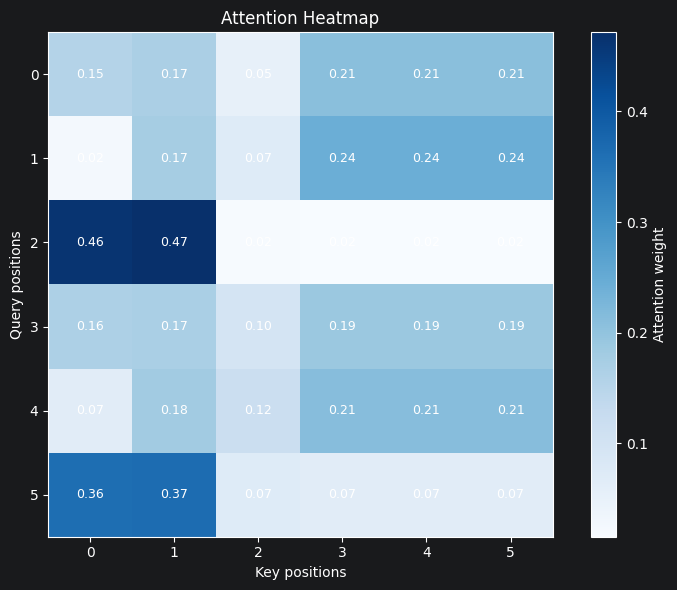

In [9]:
# Создаём данные с предсказуемым паттерном внимания
seq_len = 6
d_k = 4

# Q — запросы для каждой позиции
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

# Настраиваем первые 3 Query и последние 3 Key быть похожими
Q[:, :3, :] = 0
K[:, 3:, :] = 0
Q[:, :3, :] = Q[:, 3:, :] * 2  # усиливаем сходство

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# Визуализируем матрицу внимания в виде тепловой карты
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention weight')
plt.xlabel('Key positions')
plt.ylabel('Query positions')
plt.title('Attention Heatmap')
plt.xticks(range(seq_len))
plt.yticks(range(seq_len))
for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[0, i, j].item()
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 4.4 Маскировка: Padding Mask

В реальных данных последовательности имеют разную длину. Мы паддим (дополняем) короткие последовательности специальным PAD-токеном и маскируем его, чтобы он не влиял на attention.

Padding mask:
tensor([[[ True,  True,  True, False, False]],

        [[ True,  True,  True,  True,  True]]])


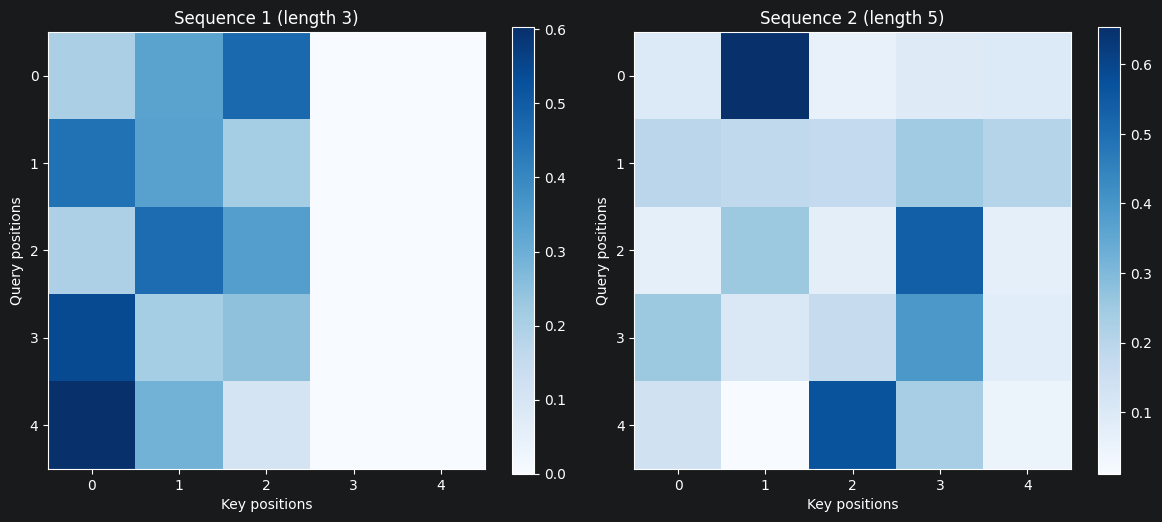

In [10]:
# Padding mask: чтобы модель не «смотрела» на padding-токены
batch, seq_len, d_k = 2, 5, 8
# Две последовательности разной длины: 3 и 5 токенов
lengths = torch.tensor([3, 5])

# Создаём маску: True для валидных позиций (длина >= позиции)
mask = torch.arange(seq_len).unsqueeze(0) < lengths.unsqueeze(1)  # (batch, seq_len)
mask = mask.unsqueeze(1)  # (batch, 1, seq_len) — для broadcasting с scores
print(f"Padding mask:\n{mask}")

Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

# Сравниваем: в первой seq padding-токены имеют нулевой вес
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2):
    ax = axes[i]
    im = ax.imshow(attn_weights[i].detach().numpy(), cmap='Blues')
    ax.set_title(f'Sequence {i+1} (length {lengths[i].item()})')
    ax.set_xlabel('Key positions')
    ax.set_ylabel('Query positions')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 4.5 Демонстрация на синтетических данных: поиск соответствий

Создадим задачу, где внимание естественно возникает: нужно найти, какие элементы одной последовательности соответствуют элементам другой.

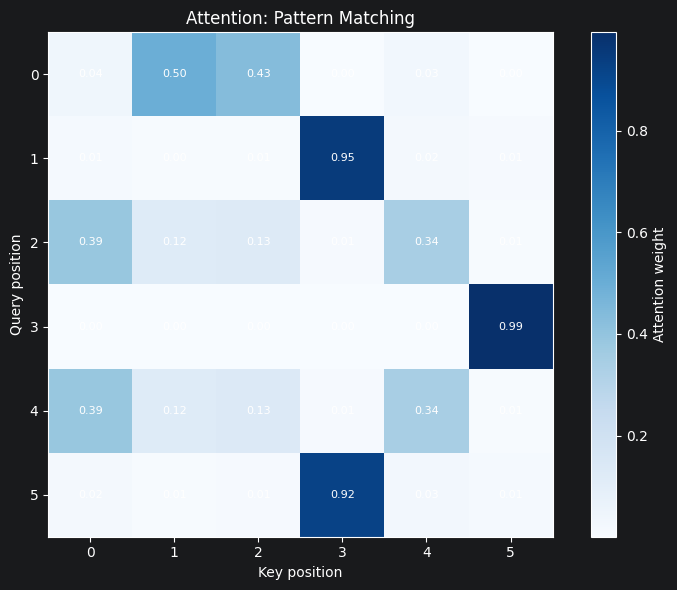

In [11]:
# Демонстрация: поиск соответствий между последовательностями
# Генерируем последовательности с повторяющимися паттернами
torch.manual_seed(42)
n_patterns = 4
d_k = 16
seq_len = 6

# Создаём случайные шаблоны (эталонные векторы)
patterns = torch.randn(n_patterns, d_k)

# Q и K — зашумлённые версии случайно выбранных шаблонов
Q = patterns[torch.randint(0, n_patterns, (seq_len,))] + 0.1 * torch.randn(seq_len, d_k)
K = patterns[torch.randint(0, n_patterns, (seq_len,))] + 0.1 * torch.randn(seq_len, d_k)
V = K.clone()  # Value = Key (identity attention)

Q, K, V = Q.unsqueeze(0), K.unsqueeze(0), V.unsqueeze(0)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

# Тёплые цвета = сильное внимание между соответствующими позициями
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights[0].detach().numpy(), cmap='Blues')
plt.colorbar(label='Attention weight')
plt.title('Attention: Pattern Matching')
plt.xlabel('Key position')
plt.ylabel('Query position')
for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[0, i, j].item()
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 4.6 Сравнение с оптимизированной реализацией PyTorch

PyTorch предоставляет `torch.nn.functional.scaled_dot_product_attention`. Сравним результаты.

In [12]:
# Сравниваем нашу реализацию с оптимизированной F.scaled_dot_product_attention
torch.manual_seed(123)
batch, seq_len, d_k = 4, 8, 32
Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

# Наша реализация
output_manual, attn_manual = scaled_dot_product_attention(Q, K, V)

# Встроенная оптимизированная реализация PyTorch
output_torch = F.scaled_dot_product_attention(Q, K, V)

# Проверяем: результаты должны совпадать с высокой точностью
diff = (output_manual - output_torch).abs().max().item()
print(f"Max difference: {diff:.2e}")
print(f"Outputs match: {torch.allclose(output_manual, output_torch, atol=1e-6)}")


Max difference: 2.98e-07
Outputs match: True


In [13]:
# Бенчмарк скорости: наша реализация vs PyTorch
import time

batch, seq_len, d_k = 16, 128, 64
Q = torch.randn(batch, seq_len, d_k, device=device)
K = torch.randn(batch, seq_len, d_k, device=device)
V = torch.randn(batch, seq_len, d_k, device=device)

def bench(fn, name, n_runs=20):
    # warmup: прогреваем GPU/CPU
    for _ in range(3):
        fn()
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    
    start = time.perf_counter()
    for _ in range(n_runs):
        fn()
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    elapsed = (time.perf_counter() - start) / n_runs
    print(f"{name:30s}: {elapsed*1000:.3f} ms")
    return elapsed

manual_time = bench(lambda: scaled_dot_product_attention(Q, K, V), "Manual attention")
torch_time = bench(lambda: F.scaled_dot_product_attention(Q, K, V), "F.scaled_dot_product_attention")
print(f"Speedup: {manual_time / torch_time:.1f}x")


Manual attention              : 0.070 ms
F.scaled_dot_product_attention: 0.123 ms
Speedup: 0.6x


## 4.7 Визуализация: влияние масштабирования на softmax

Демонстрируем, почему деление на $\sqrt{d_k}$ критично.

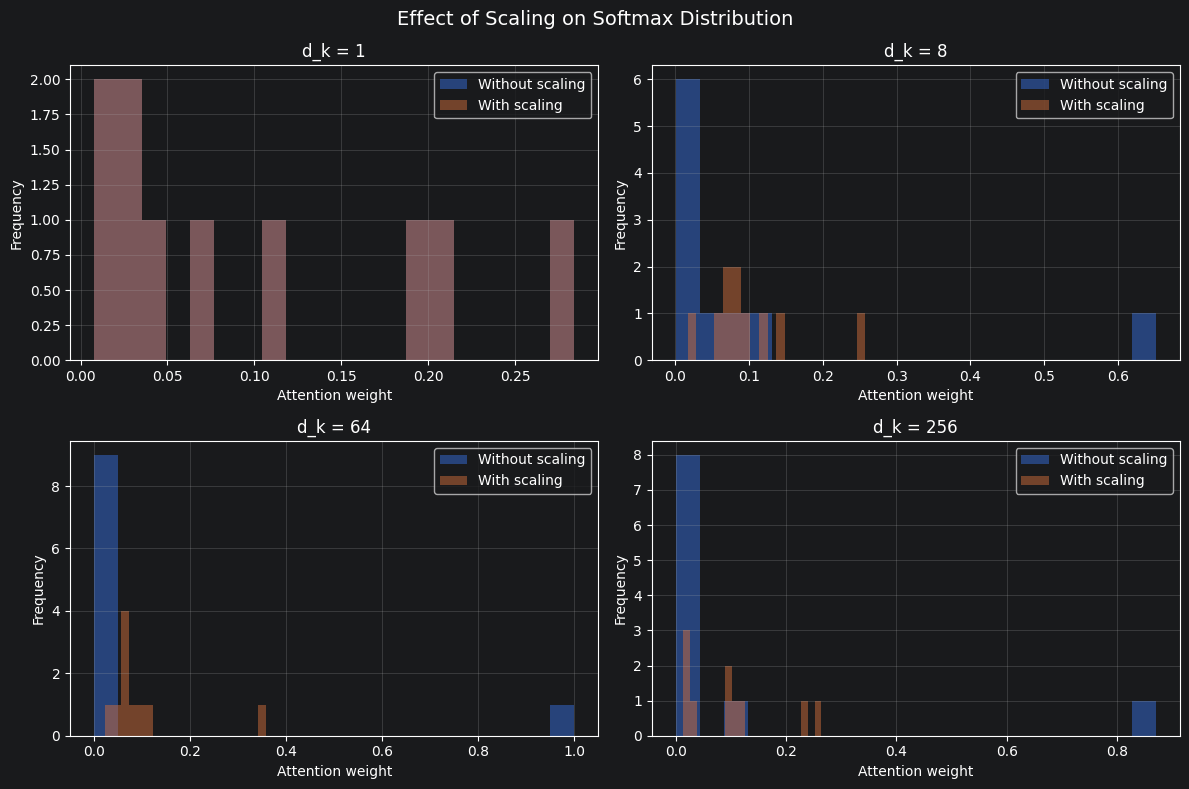

In [14]:
# Визуализация: почему нужно делить на sqrt(d_k)?
# Без масштабирования softmax становится too sharp (one-hot) или too flat (uniform)
dims = [1, 8, 64, 256]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, d_k in zip(axes.flat, dims):
    Q = torch.randn(1, 10, d_k)
    K = torch.randn(1, 10, d_k)
    
    scores = Q @ K.transpose(-2, -1)
    scores_scaled = scores / math.sqrt(d_k)
    
    # Распределение вероятностей softmax с масштабированием и без
    probs = F.softmax(scores, dim=-1)[0, 0].detach().numpy()
    probs_scaled = F.softmax(scores_scaled, dim=-1)[0, 0].detach().numpy()
    
    ax.hist(probs, bins=20, alpha=0.5, label='Without scaling')
    ax.hist(probs_scaled, bins=20, alpha=0.5, label='With scaling')
    ax.set_title(f'd_k = {d_k}')
    ax.set_xlabel('Attention weight')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Scaling on Softmax Distribution', fontsize=14)
plt.tight_layout()
plt.show()


In [18]:
# Подводим итог
print("=== Scaled Dot-Product Attention complete ===")
print("Topics covered:")
print("  - Scaled Dot-Product Attention from scratch")
print("  - Q, K, V intuition and mathematics")
print("  - Attention heatmap visualization")
print("  - Padding mask for variable-length sequences")
print("  - Pattern matching demo on synthetic data")
print("  - Comparison with F.scaled_dot_product_attention")
print("  - Performance benchmark")
print("  - Why scaling by sqrt(d_k) matters")


=== Scaled Dot-Product Attention complete ===
Topics covered:
  - Scaled Dot-Product Attention from scratch
  - Q, K, V intuition and mathematics
  - Attention heatmap visualization
  - Padding mask for variable-length sequences
  - Pattern matching demo on synthetic data
  - Comparison with F.scaled_dot_product_attention
  - Performance benchmark
  - Why scaling by sqrt(d_k) matters
